# NYC Taxi Trip Duration Prediction

## Project Overview

This project focuses on predicting the total duration of taxi trips in New York City using historical trip records. The dataset contains information about individual taxi rides, including pickup and drop-off locations, pickup and drop-off times, passenger count, vendor information, and trip duration.

The main objective of this project is to build a regression model that can estimate how long a taxi trip will take based on trip-related features. Although the raw dataset has a limited number of columns, the real challenge comes from feature engineering. Important patterns can be extracted from datetime values, geographic coordinates, distance calculations, traffic-related time periods, and pickup/drop-off location behavior.

This project helps demonstrate practical skills in regression modeling, geospatial feature engineering, time-based feature extraction, outlier handling, and model evaluation. It is useful for understanding real-world transportation problems where travel time depends on distance, location, time of day, weekday/weekend effects, and city traffic patterns.

## Dataset Description

The dataset includes taxi trip records with features such as:

- `id`: Unique identifier for each trip
- `vendor_id`: Taxi vendor/provider information
- `pickup_datetime`: Date and time when the trip started
- `dropoff_datetime`: Date and time when the trip ended
- `passenger_count`: Number of passengers in the taxi
- `pickup_longitude` and `pickup_latitude`: Pickup location coordinates
- `dropoff_longitude` and `dropoff_latitude`: Drop-off location coordinates
- `store_and_fwd_flag`: Whether the trip record was stored before forwarding
- `trip_duration`: Total trip duration in seconds, which is the target variable

## Problem Type

This is a supervised machine learning regression problem.

The target variable is:

```python
trip_duration

In [6]:
#!pip install geopy

## 1. Setup and Data Loading

This section imports required libraries, sets plotting options, and loads the train/test datasets.

In [34]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Date and time handling
import datetime as dt
from scipy import stats

# Geospatial / distance calculation
from math import radians, sin, cos, sqrt, atan2
from geopy.distance import geodesic

# Warning control
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


### 1.1 Load Dataset

Update `DATA_DIR` if your files are in a different folder.

Expected files:

- `train.csv`
- `test.csv`

In [22]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../Data")

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (1458644, 11)
Test shape: (625134, 9)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


### 1.2 Feature Groups


In [43]:
# Target column
target_feature = "trip_duration"

# ID column
id_feature = "id"

# Categorical Features
nominal_categorical = [
    "vendor_id"
]

ordinal_categorical = [
    # No true ordinal categorical feature in this dataset
]

binary_categorical = [
    "store_and_fwd_flag"
]

categorical_features = (
    nominal_categorical
    + ordinal_categorical
    + binary_categorical
)

# Numeric Features
continuous_numeric = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]

count_numeric = [
    "passenger_count"
]

ordinal_numeric = [
    # No ordinal numeric feature in this dataset
]

numeric_features = (
    continuous_numeric
    + count_numeric
    + ordinal_numeric
)
# Datetime Features


datetime_features = [
    "pickup_datetime",
    "dropoff_datetime"
]

valid_datetime_features = [
    "pickup_datetime"
]

leakage_datetime_features = [
    "dropoff_datetime"
]

# Text Features


text_features = [
    # No full text feature in this dataset
]

# Input and Drop Features


input_features = (
    categorical_features
    + numeric_features
    + valid_datetime_features
)

drop_features = [
    id_feature,
    "dropoff_datetime"
]

# All Feature Groups

all_feature_groups = {
    "target_feature": target_feature,
    "id_feature": id_feature,

    "nominal_categorical": nominal_categorical,
    "ordinal_categorical": ordinal_categorical,
    "binary_categorical": binary_categorical,
    "categorical_features": categorical_features,

    "continuous_numeric": continuous_numeric,
    "count_numeric": count_numeric,
    "ordinal_numeric": ordinal_numeric,
    "numeric_features": numeric_features,

    "datetime_features": datetime_features,
    "valid_datetime_features": valid_datetime_features,
    "leakage_datetime_features": leakage_datetime_features,

    "text_features": text_features,

    "input_features": input_features,
    "drop_features": drop_features,
}

### 1.3 Helper Functions

Reusable functions for reports, plots, missing values, rare categories, and dominance checks.

In [44]:
def repeated_count(series):
    return series.duplicated(keep="first").sum()

def repeated_percentage(series):
    return repeated_count(series) / len(series) * 100

def safe_mode(series):
    mode_values = series.mode(dropna=False)
    return mode_values.iloc[0] if len(mode_values) > 0 else np.nan

def dominance_level(pct):
    if pct >= 90:
        return "Very High"
    elif pct >= 70:
        return "High"
    elif pct >= 50:
        return "Moderate"
    else:
        return "Low"

def cardinality_level(unique_count):
    if unique_count <= 3:
        return "Low"
    elif unique_count <= 10:
        return "Medium"
    else:
        return "High"

def numeric_basic_report(df, features):
    rows = []
    total_rows = len(df)

    for feature in features:
        data = df[feature]
        rows.append({
            "feature": feature,
            "data_type": data.dtype,
            "missing_value": data.isna().sum(),
            "missing_percentage": data.isna().mean() * 100,
            "unique_value": data.nunique(dropna=False),
            "repeated_value": repeated_count(data),
            "repeated_percentage": repeated_percentage(data),
            "min": data.min(),
            "max": data.max(),
            "mean": data.mean(),
            "median": data.median(),
            "std": data.std(),
            "skewness": data.skew(),
            "kurtosis": data.kurt(),
            "most_frequent_value": safe_mode(data),
            "most_frequent_percentage": data.value_counts(dropna=False).iloc[0] / total_rows * 100,
        })

    return pd.DataFrame(rows)

def categorical_basic_report(df, features):
    rows = []
    total_rows = len(df)

    for feature in features:
        series = df[feature].astype("object")
        clean_series = series.where(series.notna(), "Missing")
        value_counts = clean_series.value_counts(dropna=False)

        top_category = value_counts.index[0]
        top_count = value_counts.iloc[0]
        top_percentage = top_count / total_rows * 100
        unique_count = clean_series.nunique(dropna=False)

        rows.append({
            "feature": feature,
            "missing_value": series.isna().sum(),
            "missing_percentage": series.isna().mean() * 100,
            "unique_category": unique_count,
            "repeated_value": repeated_count(clean_series),
            "repeated_percentage": repeated_percentage(clean_series),
            "top_category": top_category,
            "top_count": top_count,
            "top_percentage": top_percentage,
            "cardinality_level": cardinality_level(unique_count),
            "dominance_level": dominance_level(top_percentage),
        })

    return pd.DataFrame(rows)

def frequency_table(df, features, include_missing=True):
    all_tables = []

    for feature in features:
        series = df[feature].astype("object")

        if include_missing:
            series = series.where(series.notna(), "Missing")

        freq = (
            series
            .value_counts(dropna=not include_missing)
            .reset_index()
        )
        freq.columns = ["category", "count"]
        freq["feature"] = feature
        freq["percentage"] = freq["count"] / len(df) * 100
        freq["cumulative_count"] = freq["count"].cumsum()
        freq["cumulative_percentage"] = freq["percentage"].cumsum()
        freq["rank"] = range(1, len(freq) + 1)

        freq = freq[
            ["feature", "rank", "category", "count", "percentage",
             "cumulative_count", "cumulative_percentage"]
        ]

        all_tables.append(freq)

    return pd.concat(all_tables, ignore_index=True)

def rare_category_report(df, features, threshold=1.0):
    freq = frequency_table(df, features, include_missing=True)
    rare = freq[freq["percentage"] < threshold].copy()
    return rare[["feature", "category", "count", "percentage"]].sort_values(
        by=["feature", "percentage"],
        ascending=[True, True]
    )

def top_category_summary(freq_table):
    return (
        freq_table
        .query("rank == 1")
        [["feature", "category", "count", "percentage"]]
        .rename(columns={
            "category": "top_category",
            "count": "top_count",
            "percentage": "top_percentage"
        })
        .sort_values(by="top_percentage", ascending=False)
    )

def missing_summary(df, features):
    result = pd.DataFrame({
        "feature": features,
        "missing_value": df[features].isna().sum().values,
        "missing_percentage": df[features].isna().sum().values / len(df) * 100
    })

    return result.sort_values(by="missing_percentage", ascending=False)

def plot_missing_bar(df, features, title):
    summary = missing_summary(df, features)
    plot_df = summary[summary["missing_value"] > 0]

    if plot_df.empty:
        print("No missing values found.")
        return

    plt.figure(figsize=(10, max(4, 0.35 * len(plot_df))))
    ax = sns.barplot(data=plot_df, x="missing_percentage", y="feature")
    plt.title(title)
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Feature")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=9)

    plt.tight_layout()
    plt.show()

def plot_missing_matrix(df, features, title):
    missing_cols = [col for col in features if df[col].isna().sum() > 0]

    if len(missing_cols) == 0:
        print("No missing columns found.")
        return

    plt.figure(figsize=(10, max(4, 0.25 * len(missing_cols))))
    sns.heatmap(df[missing_cols].isna(), cbar=False, yticklabels=False)
    plt.title(title)
    plt.xlabel("Features")
    plt.ylabel("Rows")
    plt.tight_layout()
    plt.show()

def plot_missing_corr(df, features, title):
    missing_cols = [col for col in features if df[col].isna().sum() > 0]

    if len(missing_cols) < 2:
        print("At least two missing columns are needed for missingness correlation.")
        return

    miss = df[missing_cols].isna().astype(int)
    valid_cols = [col for col in miss.columns if miss[col].nunique() > 1]

    if len(valid_cols) < 2:
        print("Not enough variation in missingness for correlation.")
        return

    plt.figure(figsize=(10, 7))
    sns.heatmap(miss[valid_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_category_percentages(df, features, title_prefix):
    for feature in features:
        series = df[feature].astype("object").where(df[feature].notna(), "Missing")
        plot_df = series.value_counts(dropna=False).reset_index()
        plot_df.columns = ["category", "count"]
        plot_df["percentage"] = plot_df["count"] / len(df) * 100

        plt.figure(figsize=(10, max(4, 0.35 * len(plot_df))))
        ax = sns.barplot(data=plot_df, x="percentage", y="category")
        plt.title(f"{title_prefix} - {feature}")
        plt.xlabel("Percentage (%)")
        plt.ylabel(feature)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.1f%%", fontsize=8)

        plt.tight_layout()
        plt.show()

## 2. Global Missing Value Analysis

This section checks missing values across the full training dataset.

In [45]:
global_missing = (
    train.isna().sum()
    .to_frame("missing_value")
)

global_missing["missing_percentage"] = global_missing["missing_value"] / len(train) * 100
global_missing = global_missing[global_missing["missing_value"] > 0].sort_values(
    by="missing_percentage",
    ascending=False
)

display(global_missing.round(2))

,missing_value,missing_percentage


> There are no missing values

## 3. Target Variable Analysis

The target variable is `trip_duration`.

This section analyzes the target distribution, skewness, outliers, and log transformation.

In [46]:
target_feature = "trip_duration"

In [47]:
target = target_feature

target_basic_report = pd.DataFrame({
    "feature": [target],
    "data_type": [train[target].dtype],
    "missing_value": [train[target].isna().sum()],
    "missing_percentage": [train[target].isna().mean() * 100],
    "unique_value": [train[target].nunique(dropna=False)],
    "repeated_value": [repeated_count(train[target])],
    "repeated_percentage": [repeated_percentage(train[target])],
    "min": [train[target].min()],
    "max": [train[target].max()],
    "mean": [train[target].mean()],
    "median": [train[target].median()],
    "std": [train[target].std()],
    "skewness": [train[target].skew()],
    "kurtosis": [train[target].kurt()],
})

display(target_basic_report.round(4))

,feature,data_type,missing_value,missing_percentage,unique_value,repeated_value,repeated_percentage,min,max,mean,median,std,skewness,kurtosis
0,trip_duration,int64,0,0.0,7417,1451227,99.4915,1,3526282,959.4923,662.0,5237.4317,343.1639,192131.5173


## Basic Dataset Summary

The training dataset contains **1,458,644 rows and 11 columns**, while the test dataset contains **625,134 rows and 9 columns**. The train data has two extra columns: `dropoff_datetime` and `trip_duration`. Here, `trip_duration` is the target variable, and `dropoff_datetime` is not available in the test set because it would directly reveal the trip duration.

There are **no missing values** in the dataset, which is a good starting point for analysis. However, this does not mean the data is completely clean. The dataset may still contain invalid coordinates, abnormal passenger counts, unrealistic trip durations, and outliers.

The target variable `trip_duration` is stored as an integer and represents the total trip time in seconds. Its minimum value is **1 second**, while the maximum value is **3,526,282 seconds**, which is extremely large and unrealistic for a normal taxi trip. The mean trip duration is about **959 seconds**, while the median is **662 seconds**. Since the mean is much higher than the median, the target variable is strongly right-skewed.

The skewness value is very high, around **343.16**, and the kurtosis is also extremely high. This means most trips are short, but a small number of trips have extremely large durations. These extreme values can badly affect model performance, so outlier analysis and possible log transformation of the target variable are important.

> I need to remove dropoff_datetime from train dataset because it will create overfitting on training

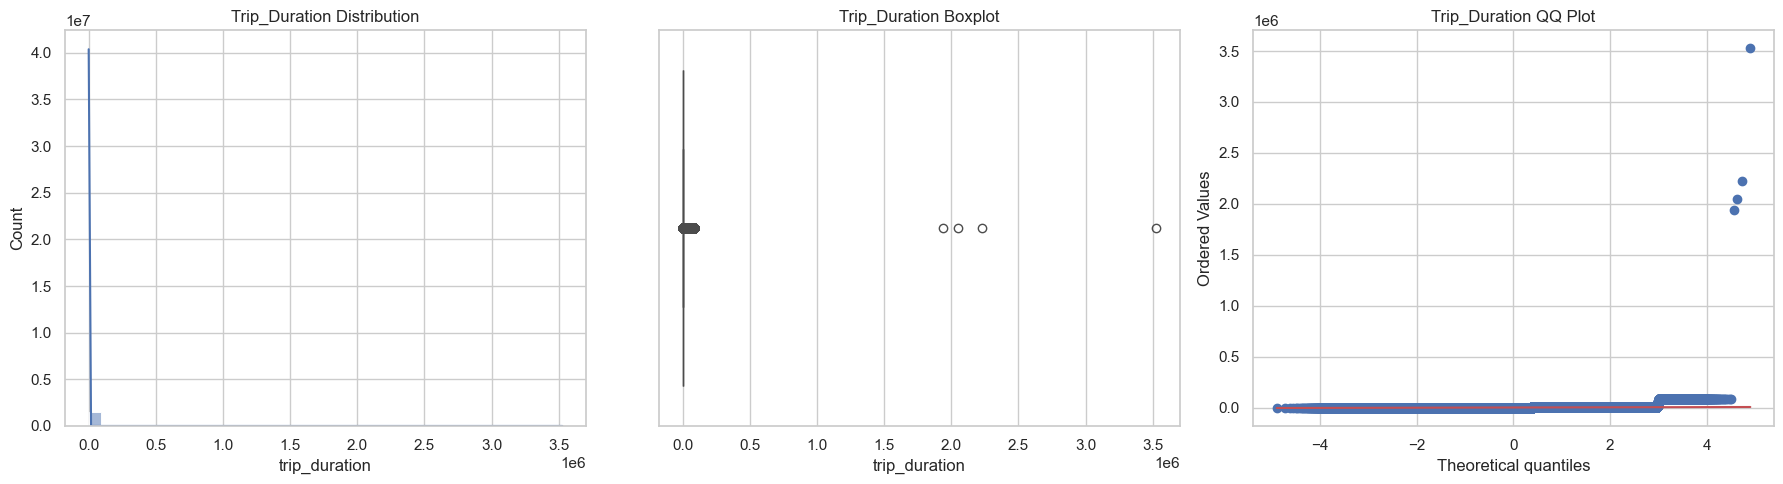

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(train[target], kde=True, bins=40, ax=axes[0])
axes[0].set_title("Trip_Duration Distribution")

sns.boxplot(x=train[target], ax=axes[1])
axes[1].set_title("Trip_Duration Boxplot")

stats.probplot(train[target], dist="norm", plot=axes[2])
axes[2].set_title("Trip_Duration QQ Plot")

plt.tight_layout()
plt.show()

### 4.1 Target Outlier Check

IQR is used only to summarize possible extreme target values.

This does not mean these rows should be removed automatically.

In [49]:
q1 = train[target].quantile(0.25)
q3 = train[target].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

target_outlier_count = ((train[target] < lower_bound) | (train[target] > upper_bound)).sum()

target_outlier_summary = pd.DataFrame({
    "feature": [target],
    "q1": [q1],
    "q3": [q3],
    "iqr": [iqr],
    "lower_bound": [lower_bound],
    "upper_bound": [upper_bound],
    "outlier_count": [target_outlier_count],
    "outlier_percentage": [target_outlier_count / len(train) * 100]
})

display(target_outlier_summary.round(4))

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,trip_duration,397.0,1075.0,678.0,-620.0,2092.0,74220,5.0883


In [50]:
target_transform_s = ({
    "version": ["Original Trip_duration", "log1p(Trip_Duration)"],
    "skewness": [train[target].skew(), saleprice_log.skew()],
    "kurtosis": [train[target].kurt(), saleprice_log.kurt()],
    "mean": [train[target].mean(), saleprice_log.mean()],
    "median": [train[target].median(), saleprice_log.median()],
})
target_transform_s

{'version': ['Original Trip_duration', 'log1p(Trip_Duration)'],
 'skewness': [np.float64(343.1639435917362), np.float64(-0.290160923725991)],
 'kurtosis': [np.float64(192131.51730712678), np.float64(3.859301838018353)],
 'mean': [np.float64(959.4922729603659), np.float64(6.466978409297406)],
 'median': [np.float64(662.0), np.float64(6.4967749901858625)]}

,version,skewness,kurtosis,mean,median
0,Original Trip_duration,343.1639,192131.5173,959.4923,662.0000
1,log1p(Trip_Duration),-0.2902,3.8593,6.4670,6.4968


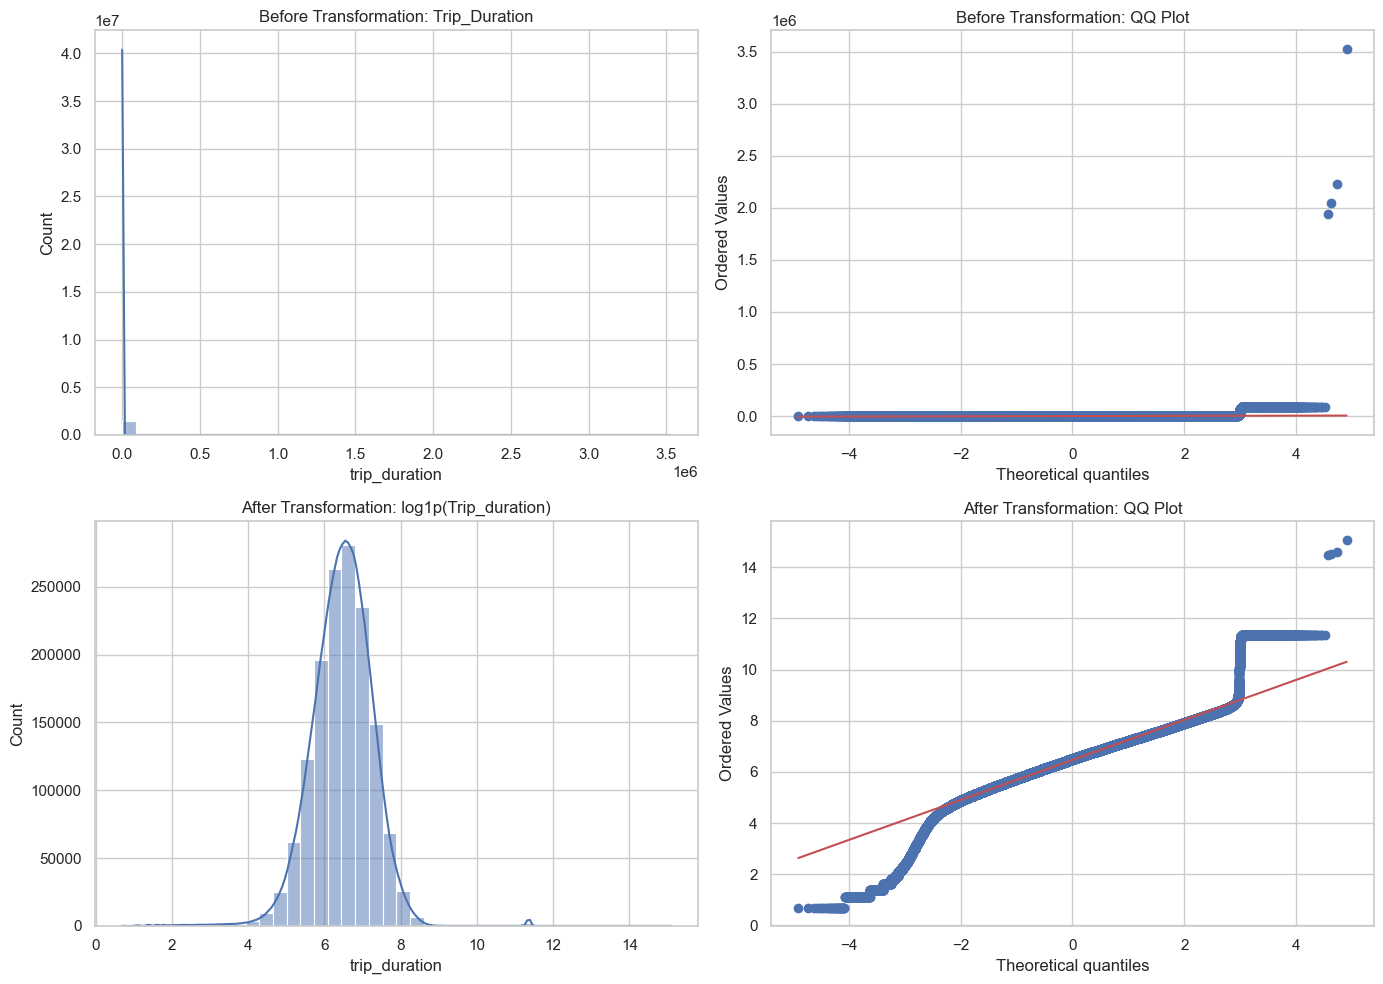

In [51]:
saleprice_log = np.log1p(train[target])

target_transform_summary = pd.DataFrame({
    "version": ["Original Trip_duration", "log1p(Trip_Duration)"],
    "skewness": [train[target].skew(), saleprice_log.skew()],
    "kurtosis": [train[target].kurt(), saleprice_log.kurt()],
    "mean": [train[target].mean(), saleprice_log.mean()],
    "median": [train[target].median(), saleprice_log.median()],
})

display(target_transform_summary.round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(train[target], kde=True, bins=40, ax=axes[0, 0])
axes[0, 0].set_title("Before Transformation: Trip_Duration")

stats.probplot(train[target], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Before Transformation: QQ Plot")

sns.histplot(saleprice_log, kde=True, bins=40, ax=axes[1, 0])
axes[1, 0].set_title("After Transformation: log1p(Trip_duration)")

stats.probplot(saleprice_log, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("After Transformation: QQ Plot")

plt.tight_layout()
plt.show()

## Target Variable Distribution Report

The original `trip_duration` distribution is extremely right-skewed, with a skewness value of **343.16** and very high kurtosis of **192131.52**. This indicates that most taxi trips are short, but a few trips have extremely large durations, which are clear extreme outliers.

The histogram and boxplot show that the majority of trip durations are concentrated near the lower range, while some unusually long trips stretch the distribution heavily to the right. The QQ plot also confirms that the original target variable is far from a normal distribution.

After applying `log1p(trip_duration)`, the distribution becomes much more balanced and close to bell-shaped. The skewness is reduced from **343.16** to **-0.29**, and the kurtosis decreases from **192131.52** to **3.86**. Also, the mean and median become very close after transformation, which indicates a more stable target distribution.

Therefore, using the log-transformed target is more suitable for regression modeling because it reduces the effect of extreme outliers and helps the model learn the general trip duration pattern more effectively.

> we can use log1p ... final

In [52]:
continuous_missing = missing_summary(train, continuous_numeric)
display(continuous_missing.round(2))

plot_missing_bar(
    train,
    continuous_numeric,
    "Missing Value Percentage - Continuous Numerical Features"
)

,feature,missing_value,missing_percentage
0,pickup_longitude,0,0.0
1,pickup_latitude,0,0.0
2,dropoff_longitude,0,0.0
3,dropoff_latitude,0,0.0


No missing values found.
